# Chapter 14: Deep Computer Vision using Convolutional Neural Networks (CNN)

Bab ini mengeksplorasi bagaimana arsitektur CNN meniru sistem visual makhluk hidup untuk mengenali pola spasial dalam gambar, mulai dari fitur sederhana hingga objek kompleks.

---

## 14.1 Arsitektur Visual Cortex
Berdasarkan penelitian David Hubel dan Torsten Wiesel, neuron pada korteks visual memiliki **Local Receptive Field** (bidang reseptif lokal).
* Neuron hanya bereaksi terhadap rangsangan di wilayah terbatas pada bidang visual.
* Beberapa neuron hanya merespons garis dengan orientasi tertentu (vertikal, horizontal, atau miring).
* Konsep ini menginspirasi pembuatan *Neocognitron* yang kemudian berevolusi menjadi CNN modern.



---

## 14.2 Convolutional Layers
Berbeda dengan lapisan *Fully Connected*, neuron pada Convolutional Layer tidak terhubung ke setiap piksel input.
* **Konektivitas Lokal**: Neuron hanya terhubung ke piksel di dalam *receptive field*-nya.
* **Hierarki Fitur**: Lapisan pertama mengenali fitur rendah (garis/tepi), lapisan berikutnya menggabungkannya menjadi fitur tingkat tinggi (bentuk/objek).
* **Stride**: Jarak antar jalur pandangan (filter) saat bergeser. Stride yang besar dapat mengurangi dimensi lapisan berikutnya.

---

## 14.3 Filters & Feature Maps
* **Filters (Kernels)**: Kumpulan bobot yang direpresentasikan sebagai gambar kecil. Filter berfungsi untuk mendeteksi pola spesifik.
* **Feature Maps**: Output dari proses konvolusi yang menonjolkan area di mana pola filter terdeteksi.
* **Stacking**: Dalam implementasi nyata, satu lapisan konvolusi memiliki banyak filter dan menghasilkan tumpukan *feature maps* secara 3D.

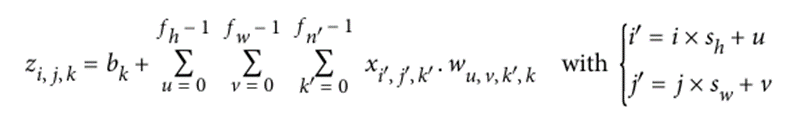

---

## 14.4 Implementasi & Memori
* **Representasi Tensor**: Dalam TensorFlow, data gambar direpresentasikan sebagai tensor 4D: `[batch_size, height, width, channels]`.
* **Kebutuhan Memori**: CNN membutuhkan RAM yang besar karena selama fase *backpropagation*, semua nilai menengah (hasil konvolusi) yang dihitung saat *forward pass* harus disimpan untuk menghitung gradien.

---

## 14.5 Pooling Layers
Tujuannya adalah melakukan *subsampling* pada gambar untuk mengurangi beban komputasi dan parameter (mengurangi overfitting).
* **Max Pooling**: Mengambil nilai maksimum dari area tertentu.
* **Average Pooling (`AvgPool2D`)**: Mengambil nilai rata-rata. Membantu menjaga informasi latar belakang namun kurang tajam dibanding Max Pooling.

---

## 14.6 Arsitektur CNN Klasik
Arsitektur CNN umumnya terdiri dari tumpukan: **Conv Layer -> ReLU -> Pooling** secara berulang, diakhiri dengan **Fully Connected (Dense) Layers**.

1. **LeNet-5**: Dirancang oleh Yann LeCun untuk digit MNIST. Menggunakan padding agar ukuran gambar tidak mengecil terlalu cepat.
2. **AlexNet**: Lebih dalam dari LeNet. Menggunakan **Dropout** dan **Data Augmentation** (memutar, menggeser, meresize gambar) untuk mencegah overfitting.
3. **VGGNet**: Menggunakan prinsip sederhana dengan filter kecil ($3 \times 3$) yang ditumpuk sangat banyak.
4. **GoogLeNet (Inception)**: Memperkenalkan **Inception Modules** yang menjalankan berbagai jenis konvolusi secara paralel untuk efisiensi parameter.
5. **ResNet (Residual Network)**: Memperkenalkan *skip connections* agar gradien bisa mengalir di jaringan yang sangat dalam (hingga 152 lapisan).
6. **Xception**: Menggunakan *Depthwise Separable Convolution* untuk memisahkan pembelajaran spasial dan pembelajaran saluran (channel).
7. **SENet (Squeeze-and-Excitation)**: Menambahkan blok SE untuk memberikan bobot pada saluran yang paling penting secara dinamis.



---

## 14.7 Deteksi Objek & Segmentasi
* **Pendeteksi Objek**: Mengklasifikasi sekaligus melokalisasi posisi objek dalam kotak (*bounding box*).
    * **Non-Max Suppression**: Teknik untuk menghapus kotak-kotak prediksi yang tumpang tindih dan hanya menyisakan yang paling akurat.
    * **YOLO (You Only Look Once)**: Arsitektur yang sangat cepat karena memproses deteksi objek sebagai satu masalah regresi dalam satu kali lewat (*single pass*).
* **Fully Convolutional Networks (FCN)**: Mengganti lapisan *Dense* terakhir dengan lapisan konvolusi agar bisa menerima input gambar dengan ukuran berapapun.
* **Semantic Segmentation**: Mengklasifikasikan setiap piksel gambar. Menggunakan **Upsampling** (seperti *bilinear interpolation*) untuk mengembalikan ukuran gambar dari fitur yang kecil ke ukuran asli.